In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Loan_Dataset_1000_rows-v2.csv to Loan_Dataset_1000_rows-v2 (1).csv


In [3]:
df = pd.read_csv("Loan_Dataset_1000_rows-v2.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 11)


,Applicant_Name,Gender,Loan_Purpose,Loan_Type,Annual_Income,Loan_Amount_Requested,Loan_Term,Credit_Score,Monthly_Expenses,Outstanding_Debt,Loan_Approval_Status
0,Nikhil Reddy,Male,Study,Secured,2200000,488000,48,756,71600,181000,1
1,Aishwarya Jadhav,Female,Gold,Secured,609000,476000,12,727,28100,202000,0
2,Radhika Singh,Female,Home,Secured,2997000,8751000,180,698,120600,645000,0
3,Kunal Bhat,Male,Gold,Secured,843000,393000,12,900,36900,52000,0
4,Praveen Deshmukh,Male,Personal,Unsecured,504000,261000,24,612,20000,102000,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['Applicant_Name', 'Gender', 'Loan_Purpose', 'Loan_Type', 'Annual_Income', 'Loan_Amount_Requested', 'Loan_Term', 'Credit_Score', 'Monthly_Expenses', 'Outstanding_Debt', 'Loan_Approval_Status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Applicant_Name         1000 non-null   object
 1   Gender                 1000 non-null   object
 2   Loan_Purpose           1000 non-null   object
 3   Loan_Type              1000 non-null   object
 4   Annual_Income          1000 non-null   int64 
 5   Loan_Amount_Requested  1000 non-null   int64 
 6   Loan_Term              1000 non-null   int64 
 7   Credit_Score           1000 non-null   int64 
 8   Monthly_Expenses       1000 non-null   int64 
 9   Outstanding_Debt       1000 non-null   int64 
 10  Loan_Approval_Status   1000 non-null   int64 
dtypes:

In [5]:
df = df.drop("Applicant_Name", axis=1)

print(df.head())

   Gender Loan_Purpose  Loan_Type  Annual_Income  Loan_Amount_Requested  \
0    Male        Study    Secured        2200000                 488000   
1  Female         Gold    Secured         609000                 476000   
2  Female         Home    Secured        2997000                8751000   
3    Male         Gold    Secured         843000                 393000   
4    Male     Personal  Unsecured         504000                 261000   

   Loan_Term  Credit_Score  Monthly_Expenses  Outstanding_Debt  \
0         48           756             71600            181000   
1         12           727             28100            202000   
2        180           698            120600            645000   
3         12           900             36900             52000   
4         24           612             20000            102000   

   Loan_Approval_Status  
0                     1  
1                     0  
2                     0  
3                     0  
4                     

In [6]:
X = df.drop("Loan_Approval_Status", axis=1)
y = df["Loan_Approval_Status"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Gender', 'Loan_Purpose', 'Loan_Type', 'Annual_Income', 'Loan_Amount_Requested', 'Loan_Term', 'Credit_Score', 'Monthly_Expenses', 'Outstanding_Debt']

Target:
Loan_Approval_Status


In [7]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded Features:")
print(X.head())

print("\nNumber of Features:", X.shape[1])

# Save feature column structure for future single-applicant inference
feature_columns = X.columns.tolist()

Encoded Features:
   Annual_Income  Loan_Amount_Requested  Loan_Term  Credit_Score  \
0        2200000                 488000         48           756   
1         609000                 476000         12           727   
2        2997000                8751000        180           698   
3         843000                 393000         12           900   
4         504000                 261000         24           612   

   Monthly_Expenses  Outstanding_Debt  Gender_Male  Loan_Purpose_Card  \
0             71600            181000         True              False   
1             28100            202000        False              False   
2            120600            645000        False              False   
3             36900             52000         True              False   
4             20000            102000         True              False   

   Loan_Purpose_Gold  Loan_Purpose_Home  Loan_Purpose_Personal  \
0              False              False                  False   
1 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 13)
Testing data: (200, 13)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [11]:
y_pred = knn.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1]


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)
print("KNN Accuracy (%):", accuracy * 100)

KNN Accuracy: 0.775
KNN Accuracy (%): 77.5


In [13]:
print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Approved", "Approved"]
))

Classification Report:

              precision    recall  f1-score   support

Not Approved       0.82      0.91      0.86       152
    Approved       0.55      0.35      0.43        48

    accuracy                           0.78       200
   macro avg       0.68      0.63      0.65       200
weighted avg       0.75      0.78      0.76       200



In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[138  14]
 [ 31  17]]


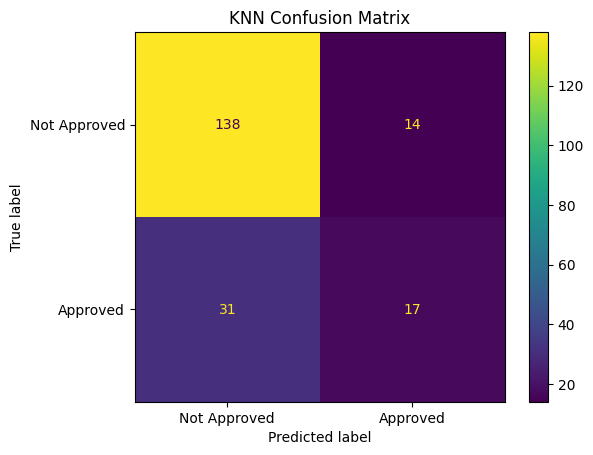

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Approved", "Approved"]
)

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [16]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

print("K values tested:", list(k_values))

K values tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


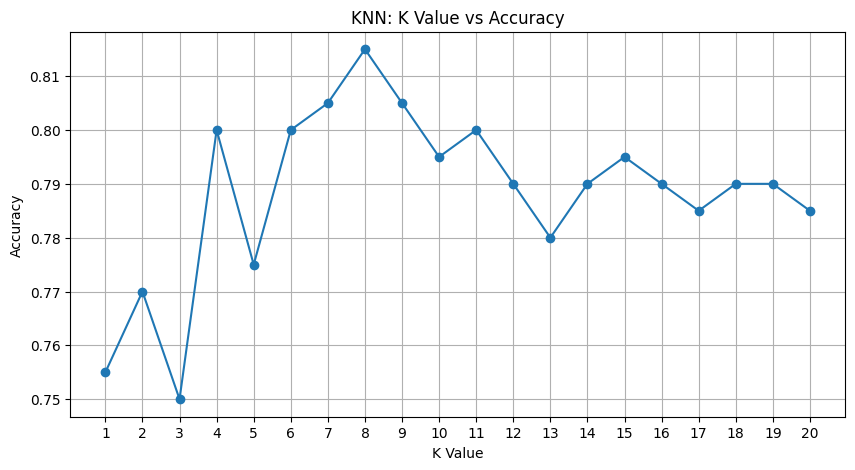

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [18]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)
print("Best Accuracy (%):", best_accuracy * 100)

Best K: 8
Best Accuracy: 0.815
Best Accuracy (%): 81.5


In [19]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

final_predictions = final_knn.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final KNN Model")
print("----------------")
print("Best K:", best_k)
print("Accuracy:", final_accuracy)
print("Accuracy (%):", final_accuracy * 100)

Final KNN Model
----------------
Best K: 8
Accuracy: 0.815
Accuracy (%): 81.5


In [20]:
print("Final KNN Classification Report:\n")
print(classification_report(
    y_test,
    final_predictions,
    target_names=["Not Approved", "Approved"]
))

Final KNN Classification Report:

              precision    recall  f1-score   support

Not Approved       0.82      0.97      0.89       152
    Approved       0.79      0.31      0.45        48

    accuracy                           0.81       200
   macro avg       0.80      0.64      0.67       200
weighted avg       0.81      0.81      0.78       200



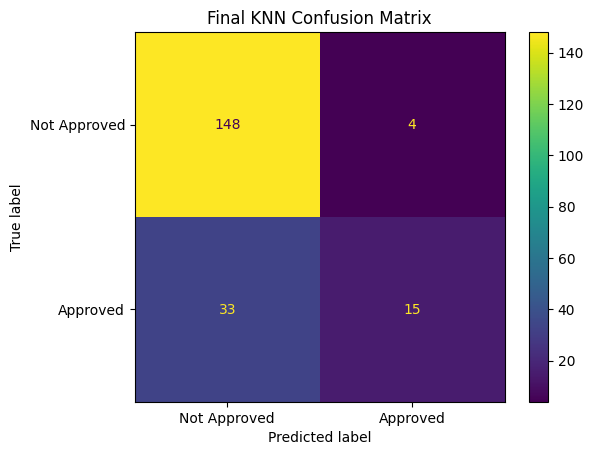

In [21]:
final_cm = confusion_matrix(y_test, final_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Not Approved", "Approved"]
)
disp.plot()
plt.title("Final KNN Confusion Matrix")
plt.show()

In [22]:
with open("knn_model.pkl", "wb") as model_file:
    pickle.dump(final_knn, model_file)

with open("scaler.pkl", "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

with open("feature_columns.pkl", "wb") as cols_file:
    pickle.dump(feature_columns, cols_file)

print("All artifacts successfully saved as .pkl files!")

All artifacts successfully saved as .pkl files!


In [23]:
# Load saved pickle artifacts
with open("knn_model.pkl", "rb") as model_file:
    loaded_knn = pickle.load(model_file)

with open("scaler.pkl", "rb") as scaler_file:
    loaded_scaler = pickle.load(scaler_file)

with open("feature_columns.pkl", "rb") as cols_file:
    loaded_columns = pickle.load(cols_file)

# Define new applicant data
new_applicant = pd.DataFrame({
    "Gender": ["Male"],
    "Loan_Purpose": ["Home"],
    "Loan_Type": ["Home Loan"],
    "Annual_Income": [800000],
    "Loan_Amount_Requested": [300000],
    "Loan_Term": [20],
    "Credit_Score": [750],
    "Monthly_Expenses": [30000],
    "Outstanding_Debt": [100000]
})

# Preprocess and align features
new_applicant_encoded = pd.get_dummies(new_applicant)
new_applicant_aligned = new_applicant_encoded.reindex(
    columns=loaded_columns,
    fill_value=0
)

# Scale features and predict
new_applicant_scaled = loaded_scaler.transform(new_applicant_aligned)
prediction = loaded_knn.predict(new_applicant_scaled)

if prediction[0] == 1:
    print("Loan Status: APPROVED")
else:
    print("Loan Status: NOT APPROVED")

Loan Status: NOT APPROVED
